# Classificação Binária

## Introdução

Este arquivo tem como objetivo desenvolver um modelo de classificação capaz de prever a sobrevivência de passageiros no naufrágio do Titanic. A análise parte de um problema clássico de aprendizado de máquina, onde buscamos identificar padrões em dados demográficos e socioeconômicos que influenciaram as chances de sobrevivência.

## Conjunto de Dados

O conjunto de dados foi obtido através do Kaggle (https://www.kaggle.com/datasets/yasserh/titanic-dataset) e contém informações como idade, sexo, classe da cabine e tarifa paga.

# Imports e Upload do Dataset

Inserção da raiz do projeto no *sys.path* para permitir o *import* do *wrapper* de classificação binária:

In [11]:
from pathlib import Path
import sys

ROOT = Path.cwd()

while not (ROOT / "wrappers").exists():
    # print(sys.path[0])
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

*Imports* necessários:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from wrappers.classifier import NeuralNetworkBinaryClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

*Upload* do conjunto de dados:

In [13]:
df = pd.read_csv("../datasets/Titanic-Dataset.csv")

# Análise Exploratória dos Dados

Nesta etapa, foi realizada uma análise exploratória para compreender a estrutura e as principais características do conjunto de dados. Para isso, serão utilizadas algumas funções do *DataFrame*, que permitem obter informações relevantes sobre o *dataset*:

* **`head()`**: exibe os cinco primeiros registros do conjunto de dados;
* **`info()`**: apresenta informações gerais, como os nomes dos atributos, a quantidade de valores não nulos e o tipo de dado de cada coluna;
* **`describe()`**: fornece estatísticas descritivas das variáveis numéricas, incluindo contagem, média, desvio padrão, valores mínimo, máximo e quartis;
* **`isnull().sum()`**: calcula a quantidade de valores ausentes (*missing values*) em cada atributo.

In [14]:
print("\nHead:")
display(df.head())
print("\nInfo:")
display(df.info())
print("\nDescribe:")
display(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())


Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None


Describe:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Valores nulos:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Significado de Cada Coluna

| Coluna          | Significado                                                                                                               | Exemplo                                                            |
| --------------- | ------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------ |
| **PassengerId** | Identificador único atribuído a cada passageiro.                  | `1`, `2`, `3`                                                      |
| **Survived**    | Indica se o passageiro sobreviveu ao desastre.             | `0 = Não`, `1 = Sim`                                               |
| **Pclass**      | Classe do passageiro (um indicador aproximado de nível socioeconômico).                                                   | `1 = Primeira Classe`, `2 = Segunda Classe`, `3 = Terceira Classe` |
| **Name**        | Nome completo do passageiro, incluindo título.                                                                            | `"Braund, Mr. Owen Harris"`                                        |
| **Sex**         | Sexo do passageiro.                                                                                                       | `male` (masculino), `female` (feminino)                            |
| **Age**         | Idade em anos. Valores ausentes (`NaN`) indicam idade desconhecida.                                                       | `22.0`, `38.0`                                                     |
| **SibSp**       | Número de irmãos(ãs) e/ou cônjuges a bordo do Titanic.                                                                    | `1` significa que viajava com um irmão(ã) ou cônjuge               |
| **Parch**       | Número de pais/mães e/ou filhos(as) a bordo do Titanic.                                                                   | `0`, `1`, `2`, etc.                                                |
| **Ticket**      | Número da passagem. Alguns passageiros compartilhavam o mesmo número quando viajavam juntos.                              | `"A/5 21171"`                                                      |
| **Fare**        | Valor pago pela passagem.                                                                                                 | `7.25`, `71.2833`                                                  |
| **Cabin**       | Número da cabine onde o passageiro estava hospedado. Valores ausentes geralmente indicam que a cabine não foi registrada. | `C85`, `C123`                                                      |
| **Embarked**    | Porto onde o passageiro embarcou no Titanic.                                                                              | `C`, `Q`, `S`                                                      |

#### Códigos da coluna Embarked

| Código | Porto de Embarque                |
| ------ | -------------------------------- |
| `C`    | Cherbourg (França)               |
| `Q`    | Queenstown (atual Cobh, Irlanda) |
| `S`    | Southampton (Inglaterra)         |

Para complementar a análise exploratória, foram gerados gráficos de alguns atributos do *dataset*, possibilitando uma melhor compreensão da distribuição e do comportamento dos dados:

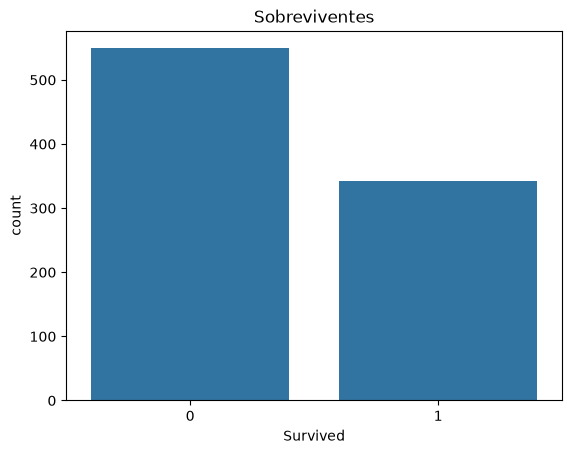

In [6]:
sns.countplot(x='Survived', data=df)
plt.title("Sobreviventes")
plt.show()

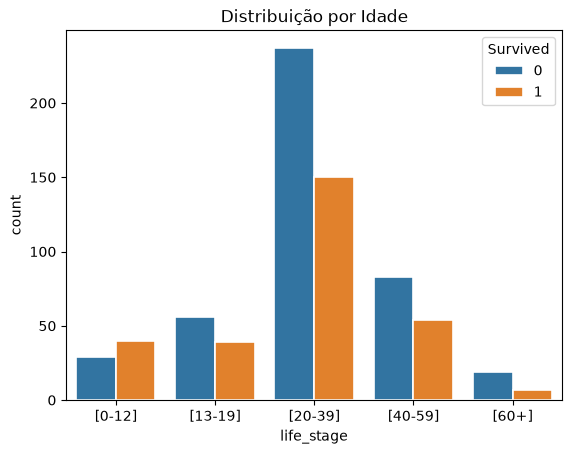

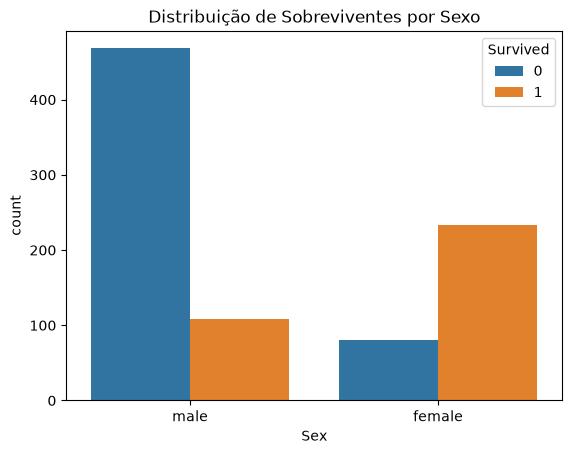

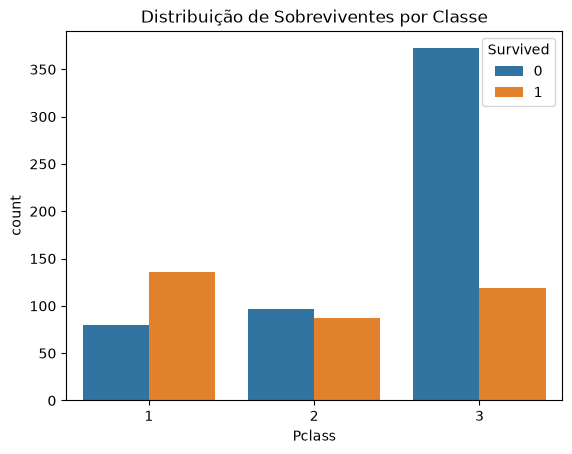

In [15]:
bins = [0, 12, 19, 39, 59, 100]
labels = ['[0-12]', '[13-19]', '[20-39]', '[40-59]', '[60+]']
df['life_stage'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
ax = sns.countplot(
    data=df,
    x='life_stage',
    hue='Survived',
    edgecolor='white',
    linewidth=1.2
)
plt.title('Distribuição por Idade')
plt.show()

plt.title("Distribuição de Sobreviventes por Sexo")
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

plt.title("Distribuição de Sobreviventes por Classe")
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

# Tratamento dos Dados

Nesta etapa, foi realizado o pré-processamento e a engenharia de atributos do conjunto de dados. Foram criadas novas variáveis (`IsAlone` e `Title`) para enriquecer as informações disponíveis, além da padronização dos títulos de passageiros e agrupamento de títulos raros. Em seguida, foram selecionadas as variáveis preditoras e a variável alvo, e definido um *pipeline* de pré-processamento para tratar valores ausentes, normalizar atributos numéricos e aplicar codificação *One-Hot Encoding* às variáveis categóricas, preparando os dados para o treinamento dos modelos.

In [16]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
df["Title"] = df["Title"].replace(
    {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
    }
)

rare_titles = [
    "Dr",
    "Rev",
    "Major",
    "Col",
    "Don",
    "Lady",
    "Sir",
    "Capt",
    "the Countess",
    "Jonkheer",
]

df["Title"] = df["Title"].replace(rare_titles, "Rare")

# X = Drop de todas as colunas pouco significativas para o problema.
X = df.drop(
    columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin", "SibSp", "Parch", "FamilySize"]
)
display(X.head())

# y = Objetivo.
y = df["Survived"]

numerical_features = ["Age", "IsAlone", "Fare"]
categorical_features = ["Embarked", "Sex", "Pclass", "Title"]

# Preencher valores faltantes com a mediana e normalizar.
numerical_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Preencher valores faltantes com o mais frequente e fazer one-hot-encoding.
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combinar os dois transformadores.
preprocessor = ColumnTransformer(
    [
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

,Pclass,Sex,Age,Fare,Embarked,life_stage,IsAlone,Title
0,3,male,22.0,7.2500,S,[20-39],0,Mr
1,1,female,38.0,71.2833,C,[20-39],0,Mrs
2,3,female,26.0,7.9250,S,[20-39],1,Miss
3,1,female,35.0,53.1000,S,[20-39],0,Mrs
4,3,male,35.0,8.0500,S,[20-39],1,Mr


# Treinamento

Nesta etapa, o conjunto de dados foi dividido em dois subconjuntos: treinamento (80%) e teste (20%), utilizando uma divisão estratificada para preservar a proporção das classes da variável alvo. Em seguida, foram definidos os modelos de classificação que seriam avaliados: uma Rede Neural Multicamadas (MLP), uma *Random Forest*, uma Máquina de Vetores de Suporte (SVM) com calibração de probabilidades e a Rede Neural implementada neste trabalho. Para cada modelo, foram especificados os hiperparâmetros selecionados na etapa de [Escolha dos Hiperparâmetros](#extra-escolha-dos-hiperparâmetros).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


models = {
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64,),
        solver='adam',
        activation='tanh',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=3000,
        random_state=42
    ),
    "RF": RandomForestClassifier(
        n_estimators=100,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        max_depth=None,
        random_state=42
    ),
    "SVM": CalibratedClassifierCV(
        SVC(
            kernel='rbf',
            gamma=0.1,
            C=1,
            random_state=42
        ),
        ensemble=False,
    ),
    "NN (Our)": NeuralNetworkBinaryClassifier(
        hidden_layers=(64, 32, 16),
        hidden_activation="tanh",
        learning_rate=0.01,
        epochs=200,
        batch_size=8,
    )
}

Nesta etapa, cada modelo foi integrado ao *pipeline* de pré-processamento e treinado utilizando o conjunto de treinamento. Após o treinamento, os modelos foram avaliados no conjunto de teste por meio da realização de predições e do cálculo das probabilidades de classificação. Para cada algoritmo, foram registradas métricas de desempenho, incluindo acurácia, precisão, *recall*, *F1-score* e área sob a curva ROC (ROC-AUC), além dos tempos de treinamento e de inferência. Por fim, foram gerados o relatório de classificação e a matriz de confusão, permitindo uma análise detalhada do desempenho de cada modelo.


 MLP
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       110
           1       0.75      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



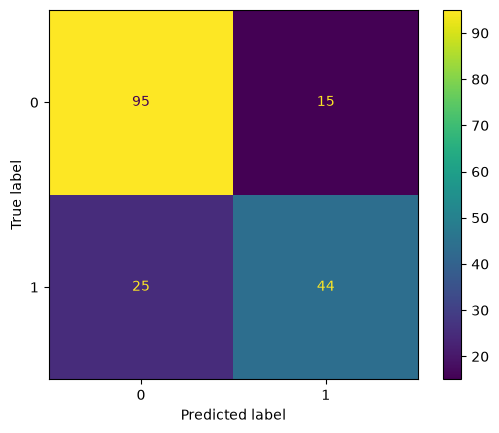


 RF
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       110
           1       0.83      0.71      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



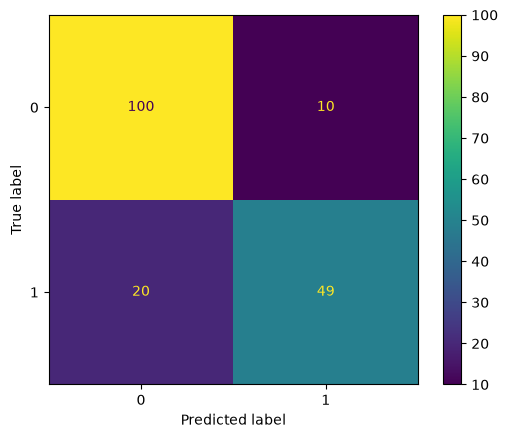


 SVM
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       110
           1       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



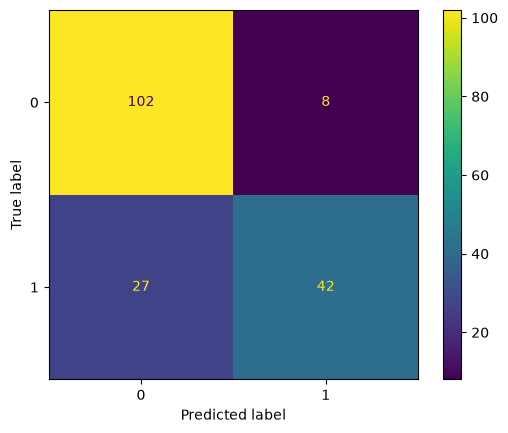


 NN (Our)
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       110
           1       0.82      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



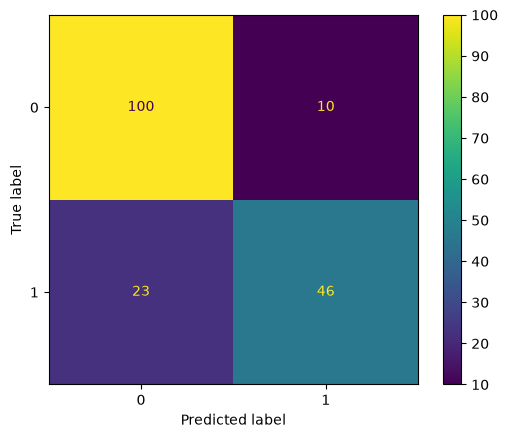

In [25]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = pipeline.predict(X_test)
    elapsed = time.time() - start
    y_prob = pipeline.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        auc,
        train_time,
        elapsed
    ])

    print("\n", name)
    print(classification_report(y_test, y_pred))
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

Após a avaliação dos modelos, os resultados obtidos foram organizados em uma tabela comparativa, reunindo as principais métricas de desempenho e os tempos de treinamento e inferência de cada algoritmo. Em seguida, foi gerado um gráfico de barras para facilitar a comparação visual entre os modelos, destacando métricas como acurácia, *F1-score*, ROC-AUC e tempo de treinamento.

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tempo de Treinamento,Tempo de Inferência
0,MLP,0.776536,0.745763,0.637681,0.687500,0.860606,0.815747,0.003801
1,RF,0.832402,0.830508,0.710145,0.765625,0.852240,0.099080,0.008510
2,SVM,0.804469,0.840000,0.608696,0.705882,0.826746,0.064807,0.007351
3,NN (Our),0.815642,0.821429,0.666667,0.736000,0.861133,1.903215,0.005205


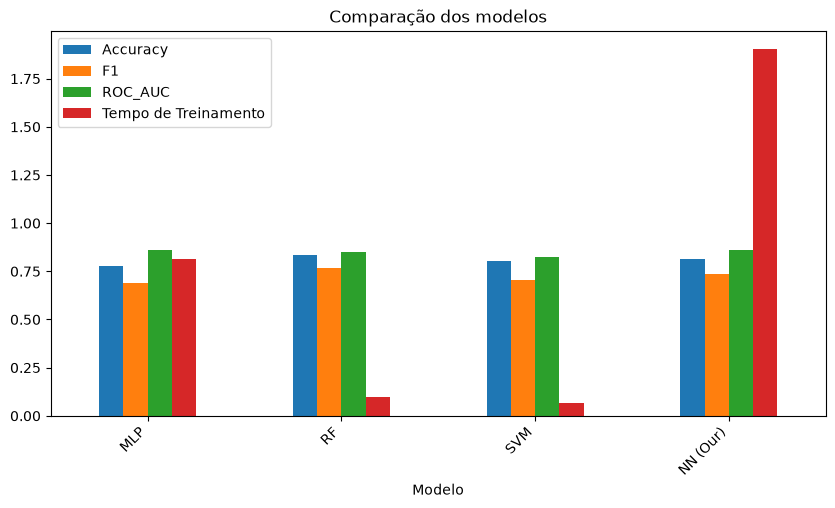

In [26]:
# Resultados em uma tabela comparativa
results_df = pd.DataFrame(
    results,
    columns=[
        'Modelo',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC',
        'Tempo de Treinamento',
        'Tempo de Inferência',
    ]
)
display(results_df)

# Gráfico das métricas
results_df.plot(
    x='Modelo',
    y=['Accuracy','F1','ROC_AUC', 'Tempo de Treinamento'],
    kind='bar',
    figsize=(10,5)
)
plt.xticks(rotation=45, ha='right')
plt.title("Comparação dos modelos")
plt.show()

# Conclusão

Os resultados obtidos demonstram que os quatro modelos apresentaram desempenho satisfatório na tarefa de classificação, porém com diferenças relevantes em termos de precisão, capacidade de generalização e custo computacional. O *Random Forest* (RF) destacou-se como o modelo de melhor desempenho geral, alcançando a maior acurácia (83.24%), o maior *F1-score* (0.7656) e o maior *recall* (0.7101) para a classe de sobreviventes, além de manter uma precisão elevada (0.8305). Esses resultados indicam um melhor equilíbrio entre a identificação correta de sobreviventes e a redução de classificações incorretas.

A rede neural desenvolvida neste trabalho (NN) apresentou o maior valor de ROC-AUC (08611), indicando a melhor capacidade de discriminação entre as classes entre os modelos avaliados. Além disso, obteve desempenho superior ao MLP em acurácia (81.56% contra 77.65%), precisão (0.8214 contra 0.7458), *recall* (06667 contra 0.6377) e *F1-score* (0.7360 contra 0.6875). Apesar desses resultados competitivos, seu desempenho permaneceu ligeiramente inferior ao do *Random Forest* nas métricas de classificação mais relevantes.

A SVM apresentou desempenho intermediário, com acurácia de 80.45% e elevada precisão (0.8400), a maior entre todos os modelos. No entanto, seu menor *recall* (0.6087) indica que o modelo deixou de identificar um número relativamente maior de passageiros sobreviventes, o que também impactou seu *F1-score* (0.7059). O MLP, por sua vez, apresentou o menor desempenho geral entre os modelos avaliados, embora tenha obtido um ROC-AUC elevado (0.8606), evidenciando boa capacidade de separação entre as classes.

Em relação ao custo computacional, a SVM apresentou o menor tempo de treinamento (0.0648 s), seguida pelo *Random Forest* (0.0991 s). A rede neural proposta demandou o maior tempo de treinamento (1.9032 s), mais de vinte vezes superior ao do *Random Forest*, sem que isso resultasse em ganhos proporcionais nas métricas de classificação. Quanto ao tempo de inferência, todos os modelos apresentaram valores bastante reduzidos, inferiores a 10 ms, sendo o MLP o mais rápido nessa etapa.

De forma geral, o *Random Forest* mostrou-se a alternativa mais eficiente para o problema estudado, combinando o melhor desempenho preditivo com baixo custo computacional. Embora a rede neural proposta tenha alcançado o maior ROC-AUC e apresentado resultados competitivos, seu tempo de treinamento significativamente superior e seu desempenho inferior nas principais métricas de classificação sugerem que, para este conjunto de dados, modelos baseados em árvores de decisão apresentam melhor relação entre desempenho e eficiência computacional.

# Extra: Escolha dos Hiperparâmetros

Nesta etapa, foi realizada a otimização dos hiperparâmetros dos modelos de classificação com o objetivo de identificar as configurações que proporcionam melhor desempenho. Para cada algoritmo, foi definido um *pipeline* contendo o pré-processamento dos dados e o classificador correspondente, além de um conjunto de hiperparâmetros candidatos. A busca foi realizada utilizando o método *Randomized Search* com validação cruzada de cinco *folds* (*5-fold Cross Validation*), avaliando diferentes combinações de hiperparâmetros de forma aleatória. Como critério de seleção, foi utilizada a métrica *F1-score*, buscando equilibrar precisão e *recall*. Ao final do processo, foram registrados o melhor valor de F1 obtido durante a validação cruzada e a combinação de hiperparâmetros correspondente para cada modelo.

In [17]:
mlp_pipeline = Pipeline(
    [("prep", preprocessor), ("clf", MLPClassifier(max_iter=3000, random_state=42))]
)

mlp_params = {
    "clf__hidden_layer_sizes": [
        (16,),
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (128, 64),
        (64, 32, 16),
    ],
    "clf__activation": ["relu", "tanh"],
    "clf__solver": ["adam", "sgd"],
    "clf__alpha": [0, 0.0001, 0.001, 0.01],
    "clf__learning_rate_init": [0.0001, 0.001, 0.01],
}

rf_pipeline = Pipeline(
    [("prep", preprocessor), ("clf", RandomForestClassifier(random_state=42))]
)

rf_params = {
    "clf__n_estimators": [100, 300, 500],
    "clf__max_depth": [None, 5, 10, 15, 20],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}

svm_pipeline = Pipeline(
    [("prep", preprocessor), ("clf", CalibratedClassifierCV(SVC(), ensemble=False))]
)

svm_params = {
    "clf__estimator__kernel": ["linear", "rbf"],
    "clf__estimator__C": [0.1, 1, 10, 100],
    "clf__estimator__gamma": ["scale", 0.1, 0.01, 0.001],
}

nn_pipeline = Pipeline(
    [("prep", preprocessor), ("clf", NeuralNetworkBinaryClassifier())]
)

nn_params = {
    "clf__hidden_layers": [
        (16,),
        (32,),
        (64,),
        (32, 16),
        (64, 32),
        (128, 64),
        (64, 32, 16),
    ],
    "clf__hidden_activation": [
        "relu",
        "sigmoid",
        "tanh",
        "leaky_relu",
        "elu",
        "selu",
    ],
    "clf__learning_rate": [
        0.00001,
        0.0001,
        0.001,
        0.01,
    ],
    "clf__epochs": [200, 500, 1000, 3000],
    "clf__batch_size": [None, 8, 16, 32, 64],
}

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from math import prod


def run_search(pipeline, params, n_iter=50):
    total_combinations = prod(len(v) for v in params.values())

    search = RandomizedSearchCV(
        pipeline,
        params,
        n_iter=min(n_iter, total_combinations),
        cv=5,
        scoring="f1",
        n_jobs=-1,
        random_state=42,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    return search


print("MLP - Buscando hiperparâmetros...")
mlp_search = run_search(mlp_pipeline, mlp_params)
print(f"  Melhor F1: {mlp_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {mlp_search.best_params_}")

print("RF - Buscando hiperparâmetros...")
rf_search = run_search(rf_pipeline, rf_params)
print(f"  Melhor F1: {rf_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {rf_search.best_params_}")

print("SVM - Buscando hiperparâmetros...")
svm_search = run_search(svm_pipeline, svm_params)
print(f"  Melhor F1: {svm_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {svm_search.best_params_}")

print("NN - Buscando hiperparâmetros...")
nn_search = run_search(nn_pipeline, nn_params)
print(f"  Melhor F1: {nn_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {nn_search.best_params_}")

MLP - Buscando hiperparâmetros...
  Melhor F1: 0.7467
  Melhores parâmetros:  {'clf__solver': 'adam', 'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (64,), 'clf__alpha': 0.001, 'clf__activation': 'tanh'}
RF - Buscando hiperparâmetros...
  Melhor F1: 0.7583
  Melhores parâmetros:  {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
SVM - Buscando hiperparâmetros...
  Melhor F1: 0.7398
  Melhores parâmetros:  {'clf__estimator__kernel': 'rbf', 'clf__estimator__gamma': 0.1, 'clf__estimator__C': 1}
NN - Buscando hiperparâmetros...
  Melhor F1: 0.7473
  Melhores parâmetros:  {'clf__learning_rate': 0.01, 'clf__hidden_layers': (64, 32, 16), 'clf__hidden_activation': 'tanh', 'clf__epochs': 200, 'clf__batch_size': 8}
